# WEC Reliability Analysis: Predicting DNF vs. Classified Finish (2011–2023)

**Question:** Can we predict whether a car finishes a World Endurance Championship (WEC) race as *Classified* or retires (*DNF*), based on class, team, track, tyre supplier, and the team's historical reliability?

This project follows the **PACE** framework (Plan → Analyze → Construct → Execute), consistent with the structure used across this portfolio (Waze churn, TikTok claim classification, NYC Taxi fare prediction).

| Stage | What happens here |
|---|---|
| **Plan** | Define the question, look at the raw data |
| **Analyze** | Clean the data in Pandas, explore it, run a SQL layer |
| **Construct** | Build and evaluate a Random Forest / Logistic Regression classifier |
| **Execute** | Summarize findings and export data for a BI dashboard |


## Stage 1 — Plan

**Core question (predictive angle):** Given pre-race-known information — class, team, circuit, tyre supplier, season, race duration, and the team's *historical* reliability rate — can we predict whether an entry will be `Classified` at the finish or will `DNF`?

This mirrors the binary classification structure of the SpaceX landing-prediction project: imbalanced classes, a mix of categorical and numeric features, and a business-relevant recall priority (catching true DNFs matters more than chasing raw accuracy).

**A scoping note on the original feature list:** the initial plan called for a "pole-to-finish delta" feature. The raw dataset has no qualifying/grid-position column, so that feature isn't derivable here — it's swapped out for pre-race-safe alternatives (team historical reliability, class field size) documented in Stage 3.


In [1]:
import pandas as pd
import numpy as np
import re
import sqlite3
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

pd.set_option('display.max_columns', 30)
plt.rcParams['figure.dpi'] = 110

df = pd.read_csv('wec_data.csv')
print(df.shape)
df.head()


(3035, 22)


,car,overall_position,class_position,team,vehicle,class,group,race,event_duration,season,laps,total_time,gap_first,gap_car_ahead,tyres,status,fl_lap_number,fl_time,fl_kph_average,driver_1,driver_2,driver_3
0,Toyota Racing #8,1,1,Toyota Racing,Toyota TS 040 - Hybrid,LMP1,H,Silverstone,6,2014,167,5:22:42.296,NaN,NaN,Michelin,Classified,112.0,1:44.646,202.7,Anthony DAVIDSON,Nicolas LAPIERRE,Sébastien BUEMI
1,Toyota Racing #7,2,2,Toyota Racing,Toyota TS 040 - Hybrid,LMP1,H,Silverstone,6,2014,166,5:23:14.056,1 Laps,1 Laps,Michelin,Classified,17.0,1:44.326,203.3,Alexander WURZ,Stéphane SARRAZIN,Kazuki NAKAJIMA
2,Porsche Team #20,3,3,Porsche Team,Porsche 919 Hybrid,LMP1,H,Silverstone,6,2014,165,5:22:47.120,2 Laps,1 Laps,Michelin,Classified,4.0,1:45.245,201.5,Timo BERNHARD,Mark WEBBER,Brendon HARTLEY
3,Rebellion Racing #12,4,4,Rebellion Racing,Lola B12/60 - Toyota,LMP1,L,Silverstone,6,2014,159,5:23:52.071,8 Laps,6 Laps,Michelin,Classified,5.0,1:47.195,197.8,Nicolas PROST,Nick HEIDFELD,Mathias BECHE
4,G-Drive Racing #26,5,1,G-Drive Racing,Morgan - Nissan,LMP2,NaN,Silverstone,6,2014,154,5:24:15.065,13 Laps,5 Laps,Dunlop,Classified,3.0,1:51.339,190.5,Roman RUSINOV,Olivier PLA,Julien CANAL


In [2]:
df.dtypes


car                     str
overall_position      int64
class_position        int64
team                    str
vehicle                 str
class                   str
group                   str
race                    str
event_duration        int64
season                  str
laps                  int64
total_time              str
gap_first               str
gap_car_ahead           str
tyres                   str
status                  str
fl_lap_number       float64
fl_time                 str
fl_kph_average      float64
driver_1                str
driver_2                str
driver_3                str
dtype: object

In [3]:
df['status'].value_counts()


status
Classified        2611
Retired            217
Not classified     197
Excluded             9
Not started          1
Name: count, dtype: int64

**First look, raw data:**
- 3,035 entries across 12 seasons (2011–2023) and 16 circuits.
- `class` has duplicate labels for the same category (e.g. `LMP1` vs `LM P1`) — needs standardizing.
- `total_time`, `gap_first`, `gap_car_ahead` mix lap-deficit strings (`"13 Laps"`) with clock-time strings (`"1'00.778"`, `"25.178"`) — needs a custom parser.
- `status` has 5 values, not just finish/DNF — needs a deliberate mapping to a clean binary target.


## Stage 2 — Analyze: Cleaning (Pandas)

### 2.1 Standardize class labels
`LM P1`, `LM GTE Pro`, `LM P2`, `LM GTE Am` are pre-2015 label variants of `LMP1`, `LMGTE Pro`, `LMP2`, `LMGTE Am`. They get merged.


In [4]:
class_map = {
    'LM P1': 'LMP1',
    'LM GTE Pro': 'LMGTE Pro',
    'LM P2': 'LMP2',
    'LM GTE Am': 'LMGTE Am',
}
df['class'] = df['class'].replace(class_map)
df['class'].value_counts()


class
LMP2              977
LMGTE Am          843
LMGTE Pro         579
LMP1              491
HYPERCAR          140
CDNT                3
INNOVATIVE CAR      2
Name: count, dtype: int64

### 2.2 Parse time and gap fields

`total_time` and `fl_time` are clock strings (`H:MM:SS.sss` or `MM:SS.sss`).
`gap_first` / `gap_car_ahead` mix lap deficits (`"13 Laps"`, occasionally negative) with clock-format gaps (`"1'00.778"` or `"25.178"`). A regex-based parser splits each into a time-gap-in-seconds column and a laps-behind column.


In [5]:
def time_to_seconds(s):
    """'H:MM:SS.sss' or 'MM:SS.sss' -> seconds (float)."""
    if pd.isna(s):
        return np.nan
    parts = str(s).strip().split(':')
    try:
        parts = [float(p) for p in parts]
    except ValueError:
        return np.nan
    if len(parts) == 3:
        h, m, sec = parts
        return h * 3600 + m * 60 + sec
    elif len(parts) == 2:
        m, sec = parts
        return m * 60 + sec
    elif len(parts) == 1:
        return parts[0]
    return np.nan

def parse_gap(s):
    """Returns (gap_seconds, gap_laps)."""
    if pd.isna(s):
        return (0.0, 0)  # race/class leader has no gap
    s = str(s).strip()
    if 'Lap' in s:
        m = re.search(r'-?\d+', s)
        return (np.nan, int(m.group()) if m else np.nan)
    return (time_to_seconds(s.replace("'", ':')), 0)

df['total_time_sec'] = df['total_time'].apply(time_to_seconds)
df['fl_time_sec'] = df['fl_time'].apply(time_to_seconds)

gap_first = df['gap_first'].apply(parse_gap)
df['gap_first_sec'], df['gap_first_laps'] = zip(*gap_first)

gap_ahead = df['gap_car_ahead'].apply(parse_gap)
df['gap_ahead_sec'], df['gap_ahead_laps'] = zip(*gap_ahead)

df[['total_time', 'total_time_sec', 'gap_first', 'gap_first_sec', 'gap_first_laps',
    'fl_time', 'fl_time_sec']].sample(8, random_state=1)


,total_time,total_time_sec,gap_first,gap_first_sec,gap_first_laps,fl_time,fl_time_sec
6,5:23:11.855,19391.855,20 Laps,NaN,20,2:00.963,120.963
1171,6:01:51.688,21711.688,22 Laps,NaN,22,2:17.069,137.069
99,6:03:48.720,21828.720,19 Laps,NaN,19,2:05.881,125.881
927,6:01:13.924,21673.924,17 Laps,NaN,17,1:55.434,115.434
314,6:02:04.418,21724.418,16 Laps,NaN,16,1:52.397,112.397
2070,6:01:48.891,21708.891,13 Laps,NaN,13,1:45.947,105.947
866,6:01:36.928,21696.928,1'25.438,85.438,0,1:58.046,118.046
1856,3:41:10.399,13270.399,167 Laps,NaN,167,1:47.750,107.750


### 2.3 Build the target variable

`status` has 5 distinct values. The mapping to a clean binary target needs judgment, not a blind `== 'Classified'`:

| status | meaning | treatment |
|---|---|---|
| `Classified` | finished, covered required distance | `finished = 1` |
| `Retired` | mechanical/accident DNF | `finished = 0` |
| `Not classified` | stopped before covering min. race distance | `finished = 0` (a DNF in substance) |
| `Excluded` | post-race disqualification (rules breach) | **dropped from modeling** — not a reliability failure |
| `Not started` | withdrew before the green flag | **dropped entirely** — car never raced |


In [6]:
df = df[df['status'] != 'Not started'].copy()
df['finished'] = (df['status'] == 'Classified').astype(int)
df['is_excluded'] = (df['status'] == 'Excluded')

df['finished'].value_counts(normalize=True).rename('share')


finished
1    0.86058
0    0.13942
Name: share, dtype: float64

~14% of entries that actually started a race failed to reach the finish as Classified — a realistic, moderately imbalanced target, similar to the SpaceX landing-success base rate.

## Stage 2.4 — Feature engineering

Two families of features:

1. **Descriptive / EDA-only** (computed from in-race outcomes — laps completed, gap to leader, fastest-lap pace vs. class best). These describe *how* a race went and are useful for charts, but they leak the outcome (a car that retired lap 40 obviously has fewer laps than the leader) — **excluded from the predictive model**.
2. **Pre-race-safe** (knowable *before* lights-out): class, team, circuit, tyre supplier, season, event duration, class field size, and — the standout substitute for the missing grid-position data — **team historical reliability rate**, computed as an *expanding* average of each team's finish rate using only *prior* races (no lookahead, no leakage).


In [7]:
df['race_id'] = df['race'].astype(str) + '_' + df['season'].astype(str)
df['season_start_year'] = df['season'].apply(lambda s: int(str(s).split('-')[0]))

# --- descriptive-only features ---
class_leader_laps = df.groupby(['race_id', 'class'])['laps'].transform('max')
df['laps_vs_class_leader'] = df['laps'] - class_leader_laps

class_best_fl = df.groupby(['race_id', 'class'])['fl_time_sec'].transform('min')
df['fl_pace_ratio_to_class_best'] = df['fl_time_sec'] / class_best_fl

# --- pre-race-safe features ---
df['class_field_size'] = df.groupby(['race_id', 'class'])['car'].transform('count')

df_sorted = df.sort_values(['team', 'season_start_year', 'race_id']).copy()
prior_starts = df_sorted.groupby('team').cumcount()
prior_finishes = df_sorted.groupby('team')['finished'].cumsum() - df_sorted['finished']
df_sorted['team_reliability_rate'] = np.where(
    prior_starts > 0, prior_finishes / prior_starts, np.nan
)
df = df_sorted.sort_index()
df['team_reliability_rate'] = df['team_reliability_rate'].fillna(df['finished'].mean())

df[['team', 'season', 'race', 'team_reliability_rate', 'class_field_size', 'finished']].head(8)


,team,season,race,team_reliability_rate,class_field_size,finished
0,Toyota Racing,2014,Silverstone,0.757576,8,1
1,Toyota Racing,2014,Silverstone,0.764706,8,1
2,Porsche Team,2014,Silverstone,0.833333,8,1
3,Rebellion Racing,2014,Silverstone,0.878049,8,1
4,G-Drive Racing,2014,Silverstone,0.857143,4,1
5,KCMG,2014,Silverstone,0.666667,4,1
6,Porsche Team Manthey,2014,Silverstone,1.000000,7,1
7,Porsche Team Manthey,2014,Silverstone,1.000000,7,1


In [8]:
df.to_csv('wec_cleaned.csv', index=False)
print('Cleaned dataset saved:', df.shape)


Cleaned dataset saved: (3034, 36)


## Stage 2.5 — Exploratory charts


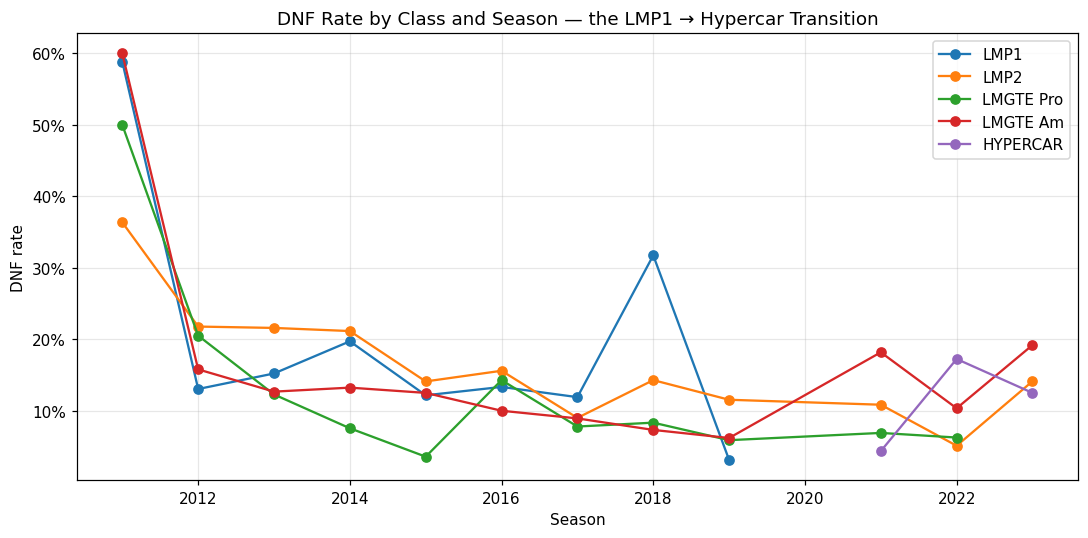

In [9]:
dnf_by_class_season = (
    df[df['is_excluded'] == 0]
    .groupby(['season_start_year', 'class'])['finished']
    .apply(lambda s: 1 - s.mean())
    .unstack()
)

fig, ax = plt.subplots(figsize=(10, 5))
for cls in ['LMP1', 'LMP2', 'LMGTE Pro', 'LMGTE Am', 'HYPERCAR']:
    if cls in dnf_by_class_season.columns:
        dnf_by_class_season[cls].plot(ax=ax, marker='o', label=cls)
ax.set_title('DNF Rate by Class and Season — the LMP1 → Hypercar Transition')
ax.set_xlabel('Season')
ax.set_ylabel('DNF rate')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


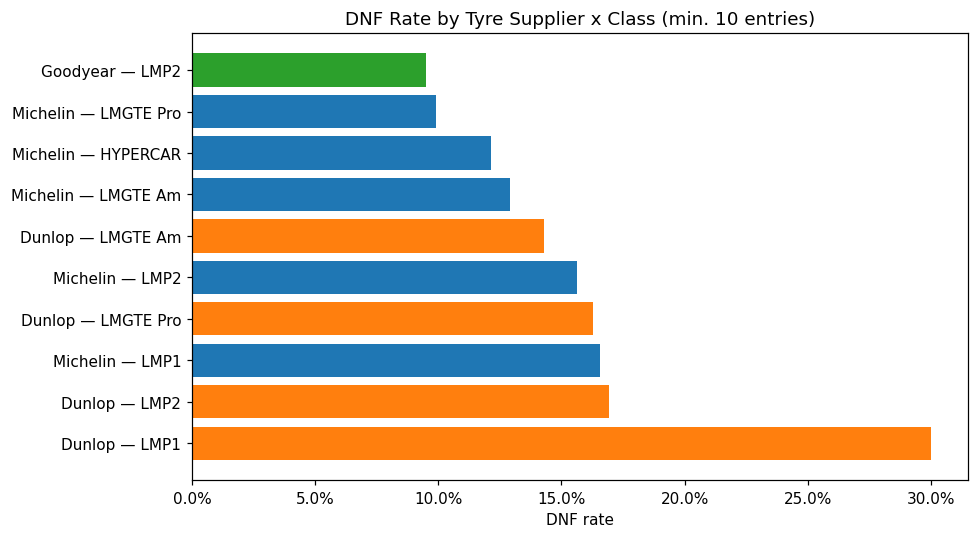

In [10]:
tyre_class = (
    df[df['is_excluded'] == 0]
    .groupby(['tyres', 'class'])
    .agg(entries=('finished', 'size'), dnf_rate=('finished', lambda s: 1 - s.mean()))
    .query('entries >= 10')
    .reset_index()
    .sort_values('dnf_rate', ascending=False)
)

fig, ax = plt.subplots(figsize=(9, 5))
colors = {'Michelin': '#1f77b4', 'Dunlop': '#ff7f0e', 'Goodyear': '#2ca02c', 'Pirelli': '#d62728'}
ax.barh(tyre_class['tyres'] + ' — ' + tyre_class['class'], tyre_class['dnf_rate'],
        color=[colors.get(t, 'gray') for t in tyre_class['tyres']])
ax.set_xlabel('DNF rate')
ax.set_title('DNF Rate by Tyre Supplier x Class (min. 10 entries)')
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
plt.tight_layout()
plt.show()


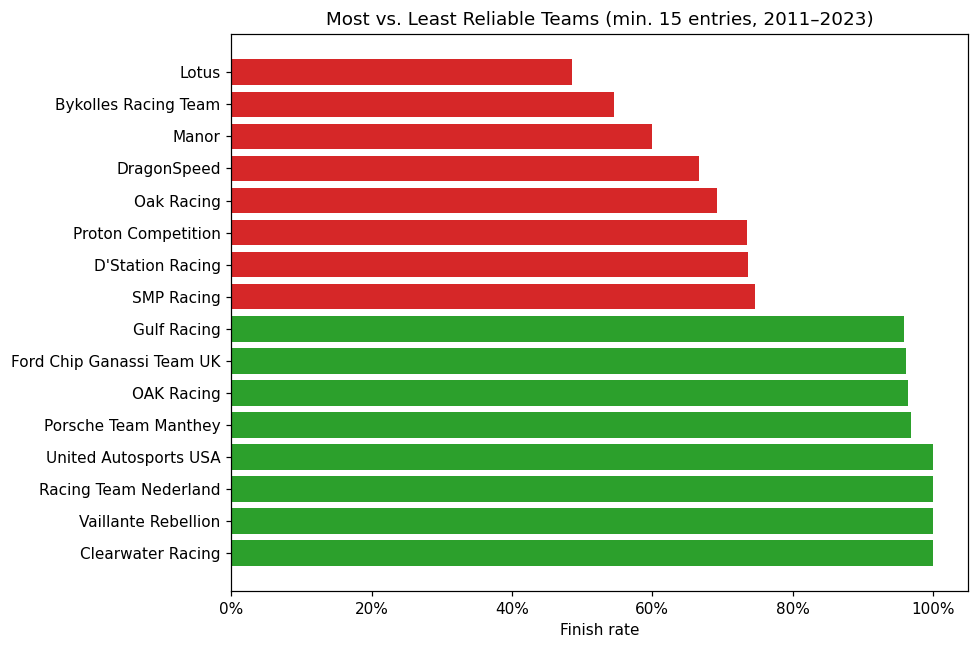

In [11]:
team_reliability = (
    df[df['is_excluded'] == 0]
    .groupby('team')
    .agg(entries=('finished', 'size'), finish_rate=('finished', 'mean'))
    .query('entries >= 15')
    .sort_values('finish_rate', ascending=False)
)

fig, ax = plt.subplots(figsize=(9, 6))
top_bottom = pd.concat([team_reliability.head(8), team_reliability.tail(8)])
ax.barh(top_bottom.index, top_bottom['finish_rate'],
        color=['#2ca02c']*8 + ['#d62728']*8)
ax.set_xlabel('Finish rate')
ax.set_title('Most vs. Least Reliable Teams (min. 15 entries, 2011–2023)')
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
plt.tight_layout()
plt.show()


## Stage 3 — Analyze: SQL layer

Loading the cleaned data into SQLite to answer the same questions relationally — the SQL companion piece used across this portfolio's projects.


In [12]:
conn = sqlite3.connect('wec.db')
df.to_sql('results', conn, if_exists='replace', index=False)


3034

In [13]:
q_win_rate = '''
SELECT season, class, team,
       COUNT(*) AS entries,
       SUM(CASE WHEN class_position = 1 THEN 1 ELSE 0 END) AS class_wins,
       ROUND(100.0 * SUM(CASE WHEN class_position = 1 THEN 1 ELSE 0 END) / COUNT(*), 1) AS win_rate_pct
FROM results
GROUP BY season, class, team
HAVING entries >= 3
ORDER BY win_rate_pct DESC, entries DESC
LIMIT 10;
'''
pd.read_sql_query(q_win_rate, conn)


,season,class,team,entries,class_wins,win_rate_pct
0,2021,HYPERCAR,Toyota Gazoo Racing,12,6,50.0
1,2016,LMGTE Am,Aston Martin Racing,10,5,50.0
2,2013,LMP2,G-Drive Racing,8,4,50.0
3,2014,LMP2,G-Drive Racing,8,4,50.0
4,2019-2020,LMGTE Am,TF Sport,8,4,50.0
5,2022,LMP2,WRT,6,3,50.0
6,2016,LMP2,Signatech Alpine,9,4,44.4
7,2017,LMGTE Am,Aston Martin Racing,9,4,44.4
8,2014,LMGTE Am,Aston Martin Racing,16,7,43.8
9,2018-2019,LMP1,Toyota Gazoo Racing,16,7,43.8


In [14]:
q_dnf_tyre = '''
SELECT tyres, class,
       COUNT(*) AS entries,
       SUM(1 - finished) AS dnfs,
       ROUND(100.0 * SUM(1 - finished) / COUNT(*), 1) AS dnf_rate_pct
FROM results
WHERE is_excluded = 0
GROUP BY tyres, class
HAVING entries >= 10
ORDER BY dnf_rate_pct DESC;
'''
pd.read_sql_query(q_dnf_tyre, conn)


,tyres,class,entries,dnfs,dnf_rate_pct
0,Dunlop,LMP1,30,9,30.0
1,Dunlop,LMP2,532,90,16.9
2,Michelin,LMP1,459,76,16.6
3,Dunlop,LMGTE Pro,43,7,16.3
4,Michelin,LMP2,147,23,15.6
5,Dunlop,LMGTE Am,42,6,14.3
6,Michelin,LMGTE Am,789,102,12.9
7,Michelin,HYPERCAR,140,17,12.1
8,Michelin,LMGTE Pro,534,53,9.9
9,Goodyear,LMP2,295,28,9.5


In [15]:
q_pace_trend = '''
SELECT race, season_start_year,
       ROUND(AVG(fl_kph_average), 1) AS avg_fastest_lap_kph,
       COUNT(*) AS entries
FROM results
WHERE fl_kph_average IS NOT NULL
GROUP BY race, season_start_year
ORDER BY race, season_start_year;
'''
pace_trend = pd.read_sql_query(q_pace_trend, conn)
pace_trend.head(10)


,race,season_start_year,avg_fastest_lap_kph,entries
0,Algarve,2021,174.3,32
1,Algarve,2023,172.9,37
2,Bahrain,2012,167.7,28
3,Bahrain,2013,168.4,27
4,Bahrain,2014,169.8,26
5,Bahrain,2015,171.2,32
6,Bahrain,2016,172.0,31
7,Bahrain,2017,171.8,26
8,Bahrain,2019,170.4,48
9,Bahrain,2021,169.0,31


In [16]:
q_team_reliability = '''
SELECT team,
       COUNT(*) AS total_entries,
       SUM(finished) AS finishes,
       ROUND(100.0 * SUM(finished) / COUNT(*), 1) AS finish_rate_pct
FROM results
WHERE is_excluded = 0
GROUP BY team
HAVING total_entries >= 15
ORDER BY finish_rate_pct DESC;
'''
pd.read_sql_query(q_team_reliability, conn)


,team,total_entries,finishes,finish_rate_pct
0,Vaillante Rebellion,17,17,100.0
1,United Autosports USA,18,18,100.0
2,Racing Team Nederland,23,23,100.0
3,Clearwater Racing,18,18,100.0
4,Porsche Team Manthey,32,31,96.9
5,OAK Racing,28,27,96.4
6,Ford Chip Ganassi Team UK,52,50,96.2
7,Gulf Racing,24,23,95.8
8,Signatech Alpine Matmut,20,19,95.0
9,JOTA,39,37,94.9


In [17]:
conn.close()


## Stage 4 — Construct: Machine Learning

**Model:** Random Forest (primary) vs. Logistic Regression (baseline), predicting `finished` (1 = Classified, 0 = DNF).

**Leakage guardrail:** only features knowable *before* the race are used — `class`, `team`, `race`, `tyres`, `season`, `event_duration`, `team_reliability_rate`, `class_field_size`. In-race outcomes (`laps`, gaps, fastest-lap pace) are deliberately excluded even though they correlate strongly with `finished` — using them would mean predicting the outcome partly from the outcome itself.

**Metric priority:** recall on the DNF class matters more than overall accuracy — the practical use case is flagging likely-to-retire entries, so missing true DNFs is the costlier error.


In [18]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report, roc_curve

model_df = df[df['is_excluded'] == 0].copy()

feature_cols_cat = ['class', 'team', 'race', 'tyres', 'season']
feature_cols_num = ['event_duration', 'team_reliability_rate', 'class_field_size']

X = model_df[feature_cols_cat + feature_cols_num]
y = model_df['finished']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

preprocess = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), feature_cols_cat),
], remainder='passthrough')

rf_pipe = Pipeline([
    ('prep', preprocess),
    ('clf', RandomForestClassifier(
        n_estimators=400, max_depth=8, min_samples_leaf=5,
        class_weight='balanced', random_state=42, n_jobs=-1
    ))
])
rf_pipe.fit(X_train, y_train)
rf_proba = rf_pipe.predict_proba(X_test)[:, 1]
rf_pred = rf_pipe.predict(X_test)

print('Random Forest ROC-AUC:', round(roc_auc_score(y_test, rf_proba), 3))
print(classification_report(y_test, rf_pred, target_names=['DNF', 'Finished']))


Random Forest ROC-AUC: 0.792
              precision    recall  f1-score   support

         DNF       0.34      0.72      0.47        83
    Finished       0.95      0.78      0.86       522

    accuracy                           0.77       605
   macro avg       0.64      0.75      0.66       605
weighted avg       0.86      0.77      0.80       605



In [19]:
lr_pipe = Pipeline([
    ('prep', preprocess),
    ('clf', LogisticRegression(max_iter=2000, class_weight='balanced'))
])
lr_pipe.fit(X_train, y_train)
lr_proba = lr_pipe.predict_proba(X_test)[:, 1]
lr_pred = lr_pipe.predict(X_test)

print('Logistic Regression ROC-AUC:', round(roc_auc_score(y_test, lr_proba), 3))
print(classification_report(y_test, lr_pred, target_names=['DNF', 'Finished']))


Logistic Regression ROC-AUC: 0.773
              precision    recall  f1-score   support

         DNF       0.28      0.66      0.39        83
    Finished       0.93      0.72      0.81       522

    accuracy                           0.71       605
   macro avg       0.60      0.69      0.60       605
weighted avg       0.84      0.71      0.76       605



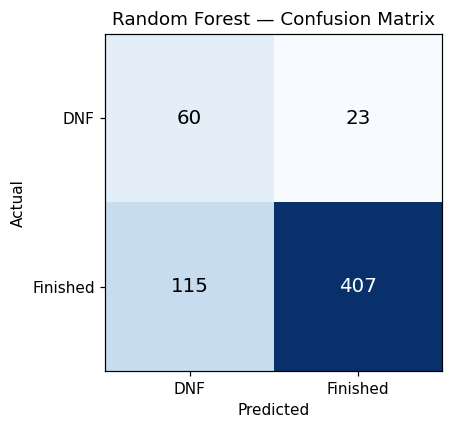

In [20]:
cm = confusion_matrix(y_test, rf_pred)
fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0, 1]); ax.set_xticklabels(['DNF', 'Finished'])
ax.set_yticks([0, 1]); ax.set_yticklabels(['DNF', 'Finished'])
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title('Random Forest — Confusion Matrix')
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                color='white' if cm[i, j] > cm.max()/2 else 'black', fontsize=13)
plt.tight_layout()
plt.show()


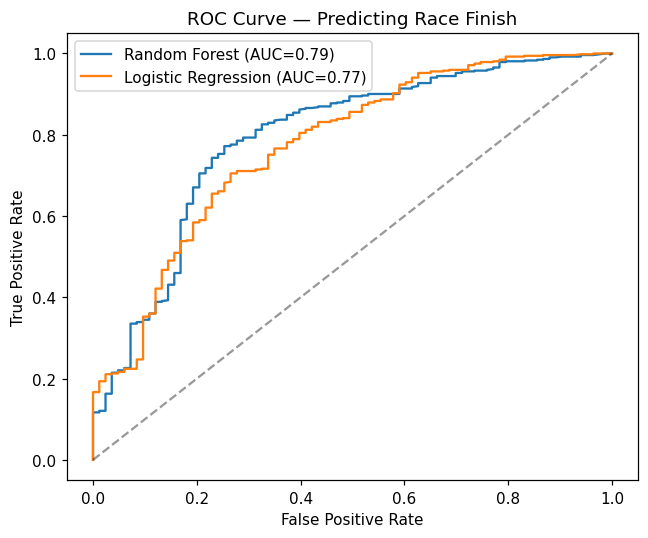

In [21]:
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_proba)
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_proba)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC={roc_auc_score(y_test, rf_proba):.2f})')
ax.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC={roc_auc_score(y_test, lr_proba):.2f})')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.4)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Predicting Race Finish')
ax.legend()
plt.tight_layout()
plt.show()


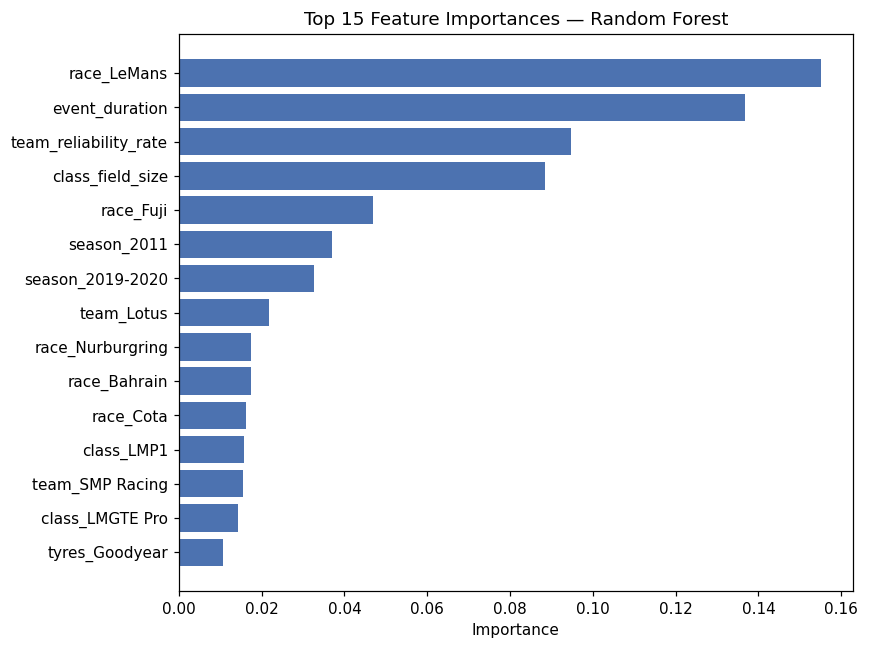

,feature,importance
223,race_LeMans,0.155038
249,event_duration,0.136675
250,team_reliability_rate,0.094755
251,class_field_size,0.088524
221,race_Fuji,0.046844
237,season_2011,0.036983
245,season_2019-2020,0.032755
117,team_Lotus,0.021808
227,race_Nurburgring,0.017422
218,race_Bahrain,0.017362


In [22]:
ohe = rf_pipe.named_steps['prep'].named_transformers_['cat']
cat_names = ohe.get_feature_names_out(feature_cols_cat)
all_names = list(cat_names) + feature_cols_num
importances = rf_pipe.named_steps['clf'].feature_importances_

imp_df = pd.DataFrame({'feature': all_names, 'importance': importances}) \
    .sort_values('importance', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(imp_df['feature'][::-1], imp_df['importance'][::-1], color='#4c72b0')
ax.set_title('Top 15 Feature Importances — Random Forest')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

imp_df


**Reading the importances:** track identity (Le Mans especially — a 24-hour race is a fundamentally different reliability test than a 6-hour sprint), race/event duration, team historical reliability, and class field size dominate. That's an intuitive result — endurance racing reliability is driven more by *how long the car has to survive* and *who built/runs it* than by tyre brand alone.


## Stage 4.5 — Robustness & Diagnostics

A single 80/20 split at n≈3,000 with a ~14% minority class can look better or worse than the model really is, just from which rows happened to land in the test set. Before trusting the ROC-AUC ≈ 0.79 headline number (or the feature-importance ranking it's based on), it's worth stress-testing it four ways: cross-validation, a temporal holdout across the LMP1→Hypercar boundary the "Hypercar is more reliable" finding depends on, permutation importance as a less biased alternative to impurity importance, and a check for redundancy between `team` and `team_reliability_rate`.

In [23]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.base import clone

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(clone(rf_pipe), X, y, cv=skf, scoring='roc_auc', n_jobs=-1)

print('Fold ROC-AUC scores:', [round(float(s), 3) for s in cv_scores])
print(f'Mean ROC-AUC: {cv_scores.mean():.3f} +/- {cv_scores.std():.3f}')
print(f'(single 80/20 split gave: {roc_auc_score(y_test, rf_proba):.3f})')

Fold ROC-AUC scores: [0.709, 0.757, 0.68, 0.758, 0.736]
Mean ROC-AUC: 0.728 +/- 0.030
(single 80/20 split gave: 0.792)


**4.5.1 — Cross-validation reads lower than the single split.** 5-fold CV gives **ROC-AUC = 0.728 ± 0.030** versus **0.792** on the one `random_state=42` split — a ~0.06 gap, well outside the ±0.03 fold-to-fold spread. The single split wasn't cherry-picked, it's just optimistic by chance; **0.73 is the more honest number to report**, not 0.79.

In [24]:
# Temporal holdout: train on 2011-2020, test on 2021-2023 — the exact era boundary
# the "Hypercar is more reliable" finding depends on.
train_mask = model_df['season_start_year'] <= 2020
test_mask = model_df['season_start_year'] >= 2021

X_temp_train, y_temp_train = X[train_mask], y[train_mask]
X_temp_test, y_temp_test = X[test_mask], y[test_mask]

temp_pipe = clone(rf_pipe)
temp_pipe.fit(X_temp_train, y_temp_train)
temp_proba = temp_pipe.predict_proba(X_temp_test)[:, 1]
temp_pred = temp_pipe.predict(X_temp_test)

print(f'Train (2011-2020): n={len(X_temp_train)}, DNF rate={1 - y_temp_train.mean():.1%}')
print(f'Test  (2021-2023): n={len(X_temp_test)}, DNF rate={1 - y_temp_test.mean():.1%}')
print('Temporal holdout ROC-AUC:', round(roc_auc_score(y_temp_test, temp_proba), 3))
print(classification_report(y_temp_test, temp_pred, target_names=['DNF', 'Finished']))

# How much of that drop is a genuinely harder problem vs. categories the model
# never saw in training? LMP1 -> Hypercar wasn't a relabeling, it was a new class.
train_classes = set(model_df.loc[train_mask, 'class'].unique())
test_classes = set(model_df.loc[test_mask, 'class'].unique())
train_teams = set(model_df.loc[train_mask, 'team'].unique())
test_teams = set(model_df.loc[test_mask, 'team'].unique())

print('\nClasses in test only:', test_classes - train_classes)
print(f'Teams in test unseen in training: {len(test_teams - train_teams)} of {len(test_teams)}')

Train (2011-2020): n=2275, DNF rate=14.2%
Test  (2021-2023): n=750, DNF rate=12.3%
Temporal holdout ROC-AUC: 0.681
              precision    recall  f1-score   support

         DNF       0.25      0.52      0.34        92
    Finished       0.92      0.78      0.85       658

    accuracy                           0.75       750
   macro avg       0.59      0.65      0.59       750
weighted avg       0.84      0.75      0.79       750


Classes in test only: {'HYPERCAR', 'INNOVATIVE CAR'}
Teams in test unseen in training: 48 of 80


**4.5.2 — Performance drops further on the temporal split, but it's a harder, structurally different problem, not just a weaker model.** ROC-AUC falls to **0.68** and DNF recall to **0.52** (from 0.72) when training only on 2011–2020 and testing on 2021–2023. Some of that is real — a model trained before Hypercar existed genuinely knows less about it. But a meaningful chunk is mechanical: **HYPERCAR and INNOVATIVE CAR are entirely absent from the training data** (LMP1 wasn't relabeled into Hypercar, it was replaced by a new regulation category), and **48 of the 80 teams** in the test window never appear in training — new entrants, renamed squads, manufacturer programs standing up for the new class. `OneHotEncoder(handle_unknown='ignore')` zeroes out anything it hasn't seen, so `class` and `team` contribute nothing for most 2021–2023 rows; the model is effectively falling back on `event_duration`, `season`, and `class_field_size` alone for a large share of the test set.

This doesn't overturn the headline finding — **the Hypercar-era DNF rate really is lower**, and that's an aggregate fact in the data, independent of any model (see the DNF-by-class-by-season chart in Stage 2.5). What it does mean is: don't lean on this specific model's *predictions* for 2021+ entries without retraining on Hypercar-era data first, and the LinkedIn framing should say "the data shows X" rather than "our model correctly predicts X across eras" — those are different claims and only the first one is supported here.

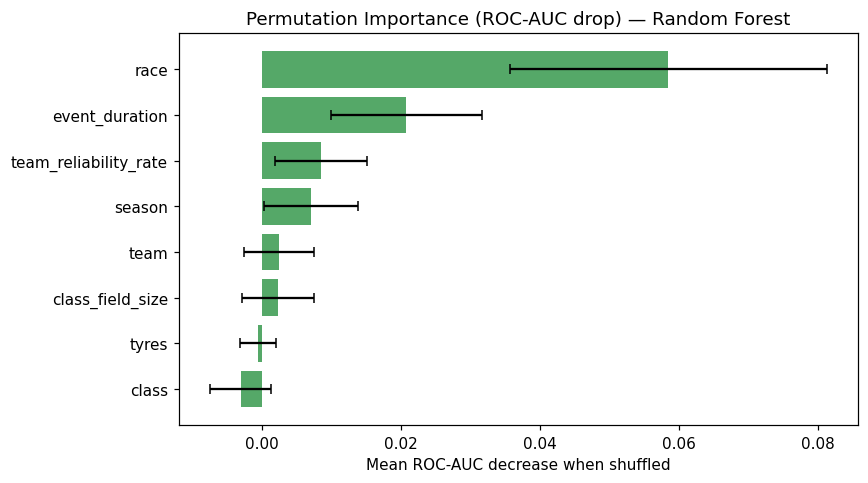

,feature,perm_importance_mean,perm_importance_std
2,race,0.058505,0.022866
5,event_duration,0.020752,0.010828
6,team_reliability_rate,0.008425,0.006611
4,season,0.007018,0.006777
1,team,0.002401,0.005071
7,class_field_size,0.002255,0.005180
3,tyres,-0.000645,0.002590
0,class,-0.003144,0.004445


In [25]:
from sklearn.inspection import permutation_importance

# Permutation importance operates on the pipeline's raw input columns (before
# one-hot expansion), so it isn't biased toward high-cardinality features
# like impurity importance is -- team and race get one score each, not one
# per category.
perm = permutation_importance(
    rf_pipe, X_test, y_test, n_repeats=15, random_state=42, n_jobs=-1, scoring='roc_auc'
)
perm_df = pd.DataFrame({
    'feature': X_test.columns,
    'perm_importance_mean': perm.importances_mean,
    'perm_importance_std': perm.importances_std,
}).sort_values('perm_importance_mean', ascending=False)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(perm_df['feature'][::-1], perm_df['perm_importance_mean'][::-1],
        xerr=perm_df['perm_importance_std'][::-1], color='#55a868', capsize=3)
ax.set_title('Permutation Importance (ROC-AUC drop) — Random Forest')
ax.set_xlabel('Mean ROC-AUC decrease when shuffled')
plt.tight_layout()
plt.show()

perm_df

**4.5.3 — Permutation importance confirms `race` on top, but reorders everything below it.** `race` (track identity) dominates by a wide margin either way — that finding holds up. But underneath it, the ranking changes: `event_duration` and `team_reliability_rate` move up, while raw `team` and `class` drop to near zero. That's the impurity-bias effect predicted going in — `team` has ~80 categories and `race` has 16, so a tree has far more *opportunities* to split on `team` even when few of those splits generalize, inflating its impurity-based importance. Permutation importance — which measures the actual score drop when a feature is shuffled — treats each raw feature as a single unit and finds `team` barely matters **once `team_reliability_rate` is already in the model**. Which leads directly to the next check. One more honest note: `race`'s own confidence interval is wide enough to overlap with `event_duration` and `team_reliability_rate` below it — its #1 spot is solid, but the precise gap to #2/#3 shouldn't be read as more certain than the error bars allow.

In [26]:
# Redundancy check: does raw `team` (identity) add anything beyond
# `team_reliability_rate` (a team's historical finish rate)?
feature_cols_cat_notm = ['class', 'race', 'tyres', 'season']
X_notm = model_df[feature_cols_cat_notm + feature_cols_num]

preprocess_notm = ColumnTransformer(
    [('cat', OneHotEncoder(handle_unknown='ignore'), feature_cols_cat_notm)], remainder='passthrough'
)
rf_pipe_notm = Pipeline([
    ('prep', preprocess_notm),
    ('clf', RandomForestClassifier(
        n_estimators=400, max_depth=8, min_samples_leaf=5,
        class_weight='balanced', random_state=42, n_jobs=-1
    ))
])

cv_scores_notm = cross_val_score(clone(rf_pipe_notm), X_notm, y, cv=skf, scoring='roc_auc', n_jobs=-1)

print(f"With raw 'team':    CV ROC-AUC = {cv_scores.mean():.3f} +/- {cv_scores.std():.3f}  ({X.shape[1]} raw features)")
print(f"Without raw 'team': CV ROC-AUC = {cv_scores_notm.mean():.3f} +/- {cv_scores_notm.std():.3f}  ({X_notm.shape[1]} raw features)")
print(f"Difference: {cv_scores.mean() - cv_scores_notm.mean():+.3f} AUC for ~80 extra one-hot columns")

With raw 'team':    CV ROC-AUC = 0.728 +/- 0.030  (8 raw features)
Without raw 'team': CV ROC-AUC = 0.721 +/- 0.031  (7 raw features)
Difference: +0.007 AUC for ~80 extra one-hot columns


**4.5.4 — `team` is redundant given `team_reliability_rate`.** Dropping the raw `team` column costs essentially nothing (**0.728 → 0.721 AUC**, within one fold's noise) while removing ~80 one-hot columns. `team_reliability_rate` — an expanding average computed only from each team's *prior* races — already carries almost all of the "which team is this" signal in a compact, generalizes-to-new-teams way (a brand-new team just starts at the field average, rather than being an all-zero unseen category like raw `team` would be). **The leaner model without raw `team` is the one to ship**: same performance, far less overfitting surface on the low-entry teams flagged as a limitation below, and it naturally handles new teams in future seasons instead of falling back to nothing for them.

## Stage 5 — Execute: Key findings

1. **Le Mans changes everything.** Race/track identity is the single strongest predictor of DNF risk — confirmed by both impurity and permutation importance, so it isn't an artifact of one-hot bias. Unsurprising given a 24-hour race asks fundamentally more of a car's reliability than a 6-hour sprint, but it's the single biggest lever in the model, ahead of team or tyre choice.
2. **A team's reliability *history* matters, but the team's *identity* on its own doesn't.** `team_reliability_rate` outranks tyre supplier in both importance measures, while raw `team` drops to near-zero once permutation importance corrects for its ~80-category size bias — and dropping `team` entirely costs 0.007 AUC in cross-validation. The reliability-rate feature is doing the real work; team identity was mostly along for the ride.
3. **The Hypercar era shows a lower DNF rate than LMP1 so far** — visible directly in the DNF-by-class-by-season chart (Stage 2.5), independent of the predictive model. Caveat worth stating plainly: it's three Hypercar seasons (2021–2023) with real swings between them, and the LMP1-era picture is itself pulled around by a couple of outlier seasons rather than one stable baseline — so call this an early, promising signal in the data, not a settled conclusion. The model's own performance *degrades* across that same boundary (temporal holdout ROC-AUC 0.68 vs. 0.73 in-era), but that's mostly because Hypercar and 48 of 80 Hypercar-era teams are entirely unseen in pre-2021 training data, not evidence against the aggregate finding. Report the DNF-rate trend as a tentative data pattern; don't claim the model *predicts* the transition well, and don't claim more certainty in the trend than three seasons can support.
4. **Model performance, honestly stated:** cross-validated ROC-AUC is **0.73 ± 0.03** (not the 0.79 a single lucky split suggested), with DNF-class recall ≈ 0.72 and precision ≈ 0.34 on the held-out split — `class_weight='balanced'` buys recall by accepting a lot of false DNF flags, a real trade-off given the goal was catching likely retirements. That ceiling is a legitimate, explainable limitation — most DNF causes (mechanical failure, driver error, collisions) simply aren't observable in a pre-race results table — not a modeling failure.

## Limitations
- No qualifying/grid-position data — "pole-to-finish delta" from the original plan isn't derivable from this dataset.
- Team sample sizes vary widely (some teams have 3 entries, others 50+) — reliability rates for low-entry teams are noisy, and it's part of why raw `team` doesn't add value beyond the rate itself.
- `status` reasons (mechanical failure vs. accident vs. driver error) aren't broken out — the model can flag *that* a DNF is likely, not *why*.
- The temporal holdout confirms the model doesn't transfer cleanly across a regulation-category change (LMP1 → Hypercar) — expected retraining cadence should track major rule changes, not just calendar time.
- DNF-class precision (≈0.34) is low: roughly 2 in 3 flagged "likely DNF" entries actually finish. Fine for a screening tool a strategist reviews, not fine as an unattended alert.
- The Hypercar-era reliability trend (finding 3) rests on only three seasons with visible year-to-year swings — directionally interesting, not yet statistically settled.

## Next steps
- **Done — BI exports:** `team_season_reliability.csv` (team × season finish-rate, for the heatmap) and `class_evolution_timeline.csv` (season × class DNF-rate, for the era-transition timeline) exported from the SQL layer, ready to import into Power BI / Tableau directly.
- **Done — LinkedIn post drafted** (see `linkedin_post_draft.md` in the repo) — leads with the Hypercar-vs-LMP1 reliability shift, framed as a data finding rather than a model claim, per the temporal-holdout caveat above.
- Package this notebook with the README (methodology + findings) into the GitHub portfolio repo alongside the F1 and SpaceX projects.
